In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

# Set random seed for reproducibility
np.random.seed(42)

Plot saved as gaussian_distribution_curve_0.5.pdf


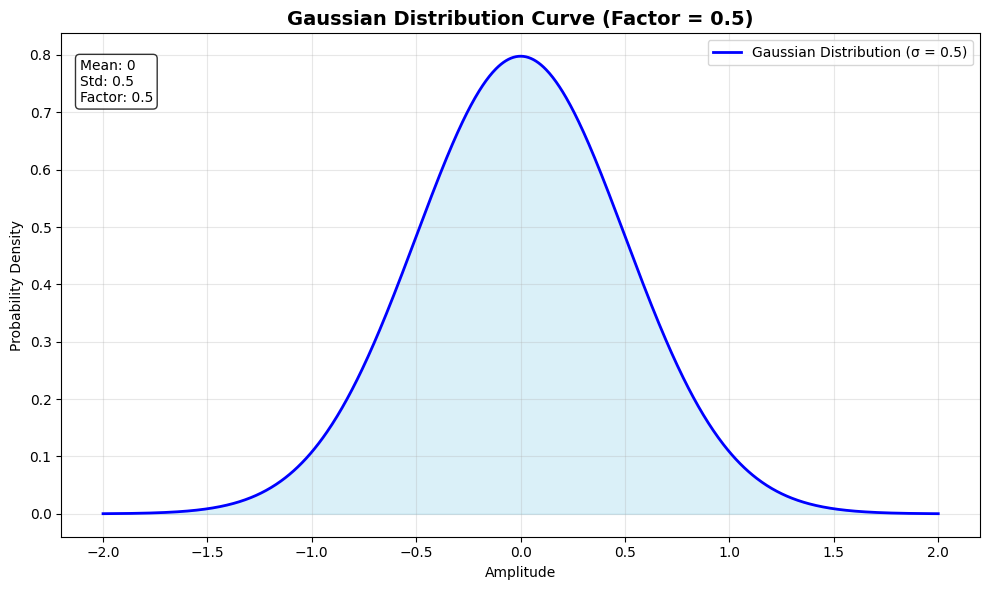

In [5]:
# Generate Gaussian noise with factor 0.5
num_samples = 1000
noise_factor = 0.5

# Generate standard Gaussian noise (mean=0, std=1)
gaussian_noise = np.random.normal(0, 1, num_samples)

# Scale by the noise factor
scaled_noise = gaussian_noise * noise_factor

# Create time axis
time = np.arange(num_samples)

# Create the plot
plt.figure(figsize=(10, 6))

# Generate x values for smooth curve
x_smooth = np.linspace(-2, 2, 1000)
# Calculate theoretical Gaussian distribution curve
y_smooth = (1 / (noise_factor * np.sqrt(2 * np.pi))) * np.exp(-0.5 * (x_smooth / noise_factor)**2)

# Plot the smooth distribution curve
plt.plot(x_smooth, y_smooth, 'b-', linewidth=2, label=f'Gaussian Distribution (σ = {noise_factor})')
plt.fill_between(x_smooth, y_smooth, alpha=0.3, color='skyblue')

plt.title('Gaussian Distribution Curve (Factor = 0.5)', fontsize=14, fontweight='bold')
plt.xlabel('Amplitude')
plt.ylabel('Probability Density')
plt.grid(True, alpha=0.3)
plt.legend()

# Add statistics text
plt.text(0.02, 0.95, f'Mean: 0\nStd: {noise_factor}\nFactor: {noise_factor}', 
         transform=plt.gca().transAxes, fontsize=10, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()

# Save as PDF
pdf_filename = 'gaussian_distribution_curve_0.5.pdf'
plt.savefig(pdf_filename, format='pdf', dpi=300, bbox_inches='tight')
print(f"Plot saved as {pdf_filename}")

# Show the plot
plt.show()

Audio loaded: 14400 samples at 32000 Hz
Duration: 0.45 seconds
Original audio plot saved as original_audio_waveform.pdf


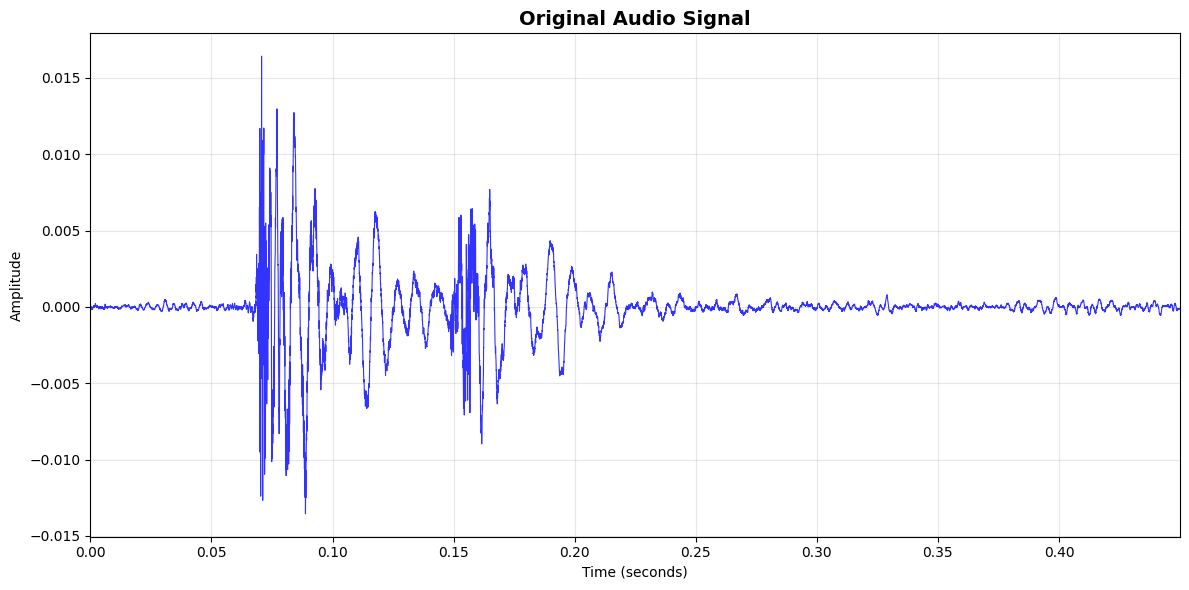

Noisy audio plot saved as noisy_audio_waveform.pdf


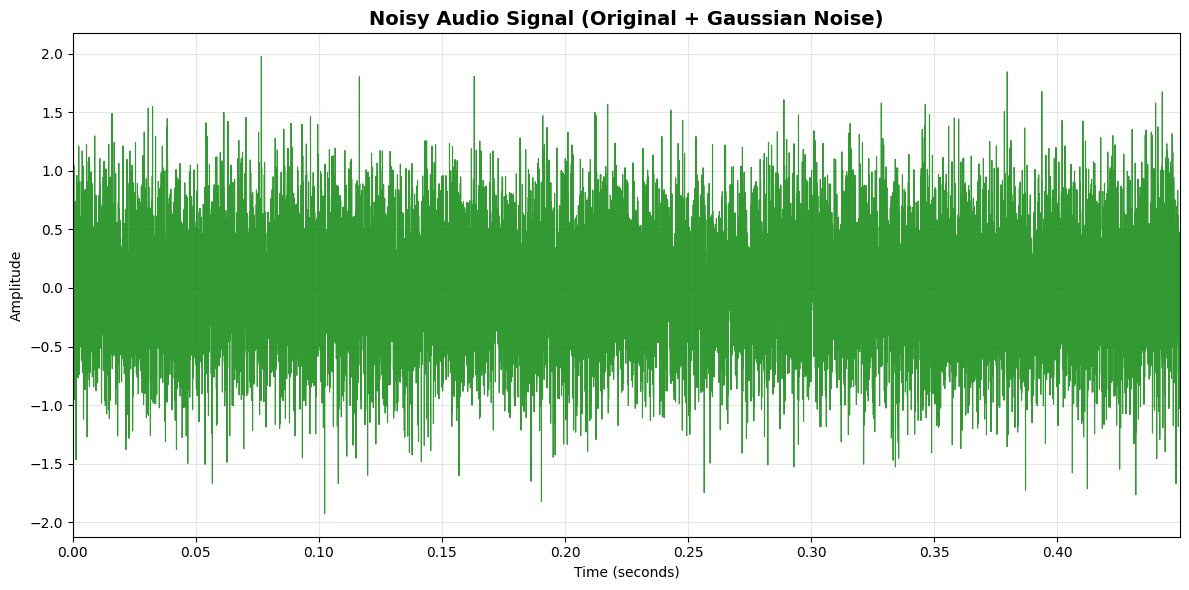


Original audio - Mean: -0.000019, Std: 0.001943
Gaussian noise - Mean: -0.000521, Std: 0.497417
Noisy audio - Mean: -0.000540, Std: 0.497417


In [7]:
import librosa
import soundfile as sf

# Load the audio file
audio_path = "/home/ali/EchoCrypt/new_dataset_zoom/t/0.wav"
audio_data, sample_rate = librosa.load(audio_path, sr=None)

print(f"Audio loaded: {len(audio_data)} samples at {sample_rate} Hz")
print(f"Duration: {len(audio_data)/sample_rate:.2f} seconds")

# Create time axis for the audio
time_audio = np.arange(len(audio_data)) / sample_rate

# Generate Gaussian noise with the same length as audio
noise_factor = 0.5
gaussian_noise = np.random.normal(0, noise_factor, len(audio_data))

# Add noise to the original audio
noisy_audio = audio_data + gaussian_noise

# Plot original audio waveform
plt.figure(figsize=(12, 6))
plt.plot(time_audio, audio_data, 'b-', alpha=0.8, linewidth=0.8)
plt.title('Original Audio Signal', fontsize=14, fontweight='bold')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')
plt.grid(True, alpha=0.3)
plt.xlim(0, time_audio[-1])
plt.tight_layout()

# Save original audio plot
plt.savefig('original_audio_waveform.pdf', format='pdf', dpi=300, bbox_inches='tight')
print("Original audio plot saved as original_audio_waveform.pdf")
plt.show()

# Plot noisy audio waveform
plt.figure(figsize=(12, 6))
plt.plot(time_audio, noisy_audio, 'g-', alpha=0.8, linewidth=0.8)
plt.title('Noisy Audio Signal (Original + Gaussian Noise)', fontsize=14, fontweight='bold')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')
plt.grid(True, alpha=0.3)
plt.xlim(0, time_audio[-1])
plt.tight_layout()

# Save noisy audio plot
plt.savefig('noisy_audio_waveform.pdf', format='pdf', dpi=300, bbox_inches='tight')
print("Noisy audio plot saved as noisy_audio_waveform.pdf")
plt.show()

# Print some statistics
print(f"\nOriginal audio - Mean: {np.mean(audio_data):.6f}, Std: {np.std(audio_data):.6f}")
print(f"Gaussian noise - Mean: {np.mean(gaussian_noise):.6f}, Std: {np.std(gaussian_noise):.6f}")
print(f"Noisy audio - Mean: {np.mean(noisy_audio):.6f}, Std: {np.std(noisy_audio):.6f}")

Model accuracy comparison plot saved as model_accuracy_comparison.pdf


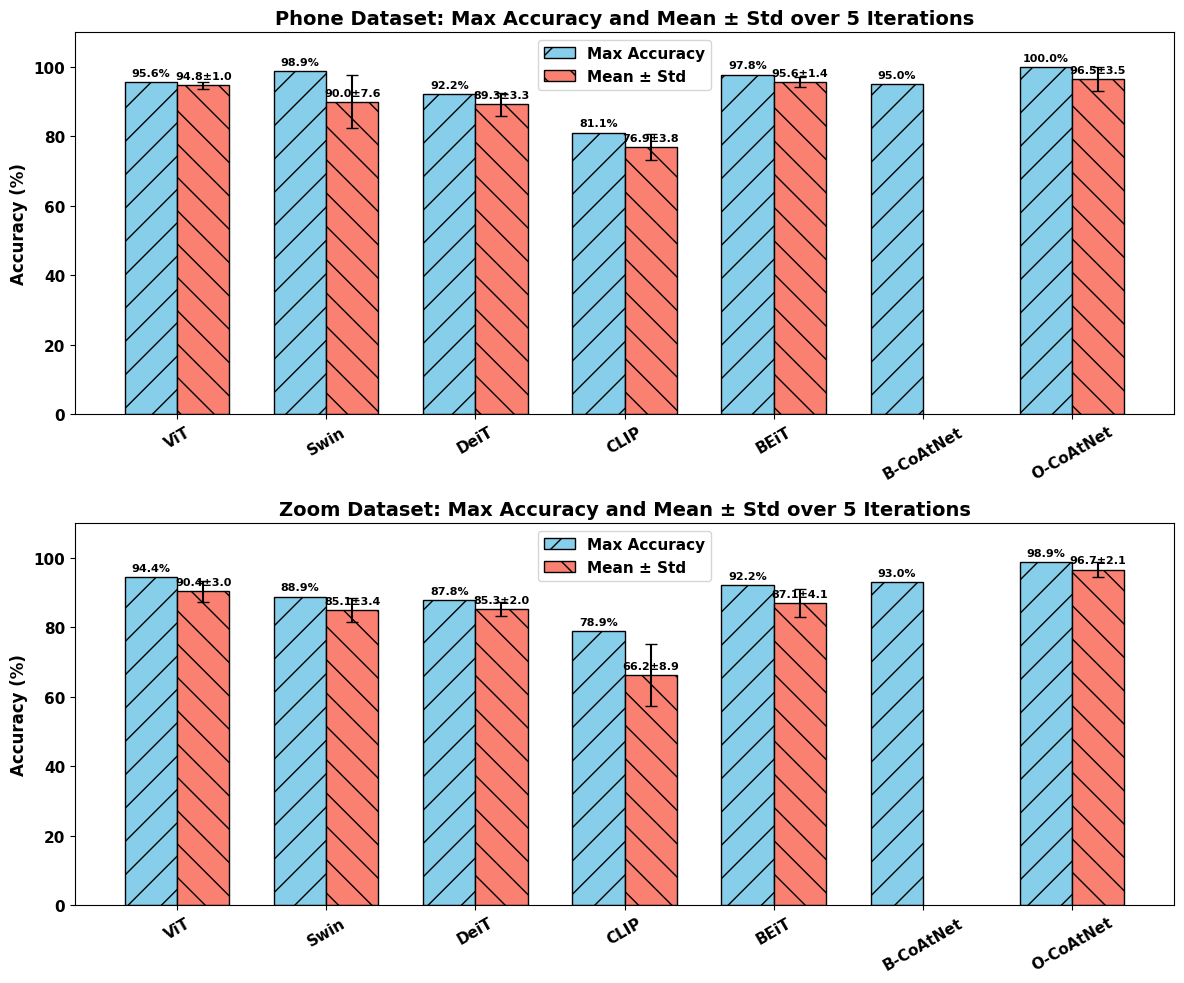

In [13]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({
    'font.size': 12,           # Increase base font size
    'font.weight': 'bold',     # Make all text bold
    'axes.labelweight': 'bold',
    'axes.titlesize': 14,      # Title font size
    'axes.titleweight': 'bold',
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11
})

# Models
models = ['ViT', 'Swin', 'DeiT', 'CLIP', 'BEiT', 'B-CoAtNet', 'O-CoAtNet']
x = np.arange(len(models))
width = 0.35

# Phone data
phone_max = [95.6, 98.9, 92.2, 81.1, 97.8, 95.0, 100.0]
phone_mean = [94.8, 90.0, 89.3, 76.9, 95.6, np.nan, 96.45]
phone_std = [1.0, 7.6, 3.3, 3.8, 1.4, np.nan, 3.5]

# Zoom data
zoom_max = [94.4, 88.9, 87.8, 78.9, 92.2, 93.0, 98.9]
zoom_mean = [90.4, 85.1, 85.3, 66.2, 87.1, np.nan, 96.67]
zoom_std = [3.0, 3.4, 2.0, 8.9, 4.1, np.nan, 2.1]

# Plotting function
def plot_accuracy(ax, title, max_vals, mean_vals, std_vals, hatch1='/', hatch2='\\', color1='skyblue', color2='salmon'):
    bars1 = ax.bar(x - width/2, max_vals, width, label='Max Accuracy', hatch=hatch1, color=color1, edgecolor='black')
    bars2 = ax.bar(x + width/2, mean_vals, width, yerr=std_vals, capsize=4,
                   label='Mean ± Std', hatch=hatch2, color=color2, edgecolor='black')

    # Annotate bars
    for i in range(len(models)):
        # Max
        ax.annotate(f'{max_vals[i]:.1f}%',
                    xy=(x[i] - width/2, max_vals[i]),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=8)
        # Mean ± std
        if not np.isnan(mean_vals[i]):
            ax.annotate(f'{mean_vals[i]:.1f}±{std_vals[i]:.1f}',
                        xy=(x[i] + width/2, mean_vals[i]),
                        xytext=(0, 3), textcoords="offset points",
                        ha='center', va='bottom', fontsize=8)

    ax.set_title(title)
    ax.set_ylabel('Accuracy (%)')
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=30)
    ax.set_ylim(0, 110)
    ax.legend()

# Create two subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

plot_accuracy(ax1, 'Phone Dataset: Max Accuracy and Mean ± Std over 5 Iterations', phone_max, phone_mean, phone_std)
plot_accuracy(ax2, 'Zoom Dataset: Max Accuracy and Mean ± Std over 5 Iterations', zoom_max, zoom_mean, zoom_std)

plt.tight_layout()
plt.savefig('model_accuracy_comparison.pdf', format='pdf', dpi=300, bbox_inches='tight')
print("Model accuracy comparison plot saved as model_accuracy_comparison.pdf")
plt.show()


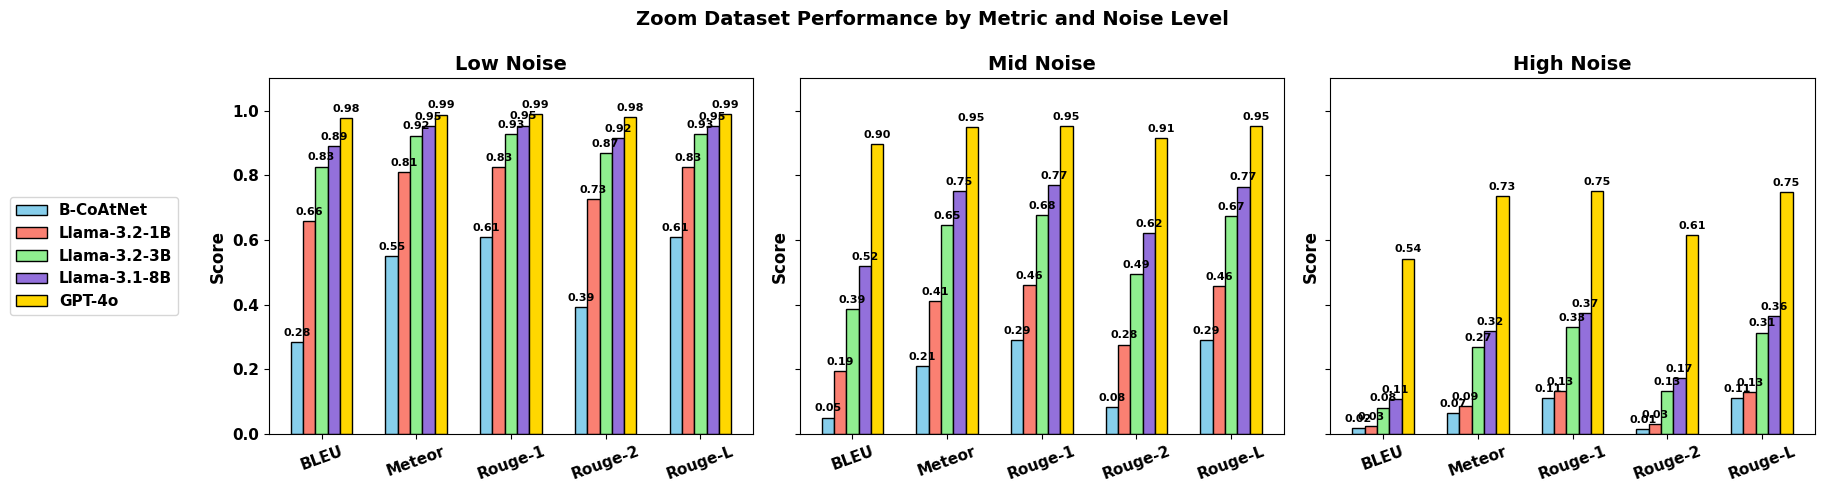

In [8]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({
    'font.size': 12,           # Increase base font size
    'font.weight': 'bold',     # Make all text bold
    'axes.labelweight': 'bold',
    'axes.titlesize': 14,      # Title font size
    'axes.titleweight': 'bold',
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11
})

# Selected models
models = ["B-CoAtNet", "Llama-3.2-1B", "Llama-3.2-3B", "Llama-3.1-8B", "GPT-4o"]

# Metrics and values for each noise level
metrics = ["BLEU", "Meteor", "Rouge-1", "Rouge-2", "Rouge-L"]
noise_levels = ["Low", "Mid", "High"]

# Each metric contains a list of shape (noise_levels x models)
values = {
    "BLEU": [
        [0.285, 0.657, 0.827, 0.891, 0.976],  # Low
        [0.050, 0.193, 0.385, 0.520, 0.896],  # Mid
        [0.018, 0.025, 0.081, 0.107, 0.542]   # High
    ],
    "Meteor": [
        [0.551, 0.811, 0.923, 0.952, 0.988],
        [0.210, 0.412, 0.646, 0.751, 0.950],
        [0.065, 0.085, 0.268, 0.319, 0.735]
    ],
    "Rouge-1": [
        [0.608, 0.826, 0.927, 0.954, 0.989],
        [0.291, 0.461, 0.676, 0.769, 0.952],
        [0.111, 0.131, 0.329, 0.373, 0.750]
    ],
    "Rouge-2": [
        [0.392, 0.726, 0.868, 0.915, 0.979],
        [0.083, 0.276, 0.493, 0.622, 0.914],
        [0.014, 0.031, 0.132, 0.172, 0.615]
    ],
    "Rouge-L": [
        [0.608, 0.826, 0.927, 0.953, 0.989],
        [0.291, 0.458, 0.673, 0.765, 0.952],
        [0.111, 0.130, 0.313, 0.364, 0.749]
    ]
}

# Plotting
fig, axs = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

colors = ['skyblue', 'salmon', 'lightgreen', 'mediumpurple', 'gold']
x = np.arange(len(metrics))
bar_width = 0.13

for i, level in enumerate(noise_levels):
    ax = axs[i]
    for j, model in enumerate(models):
        bar_values = [values[metric][i][j] for metric in metrics]
        bars = ax.bar(x + j * bar_width, bar_values, width=bar_width,
                      label=model if i == 0 else "", color=colors[j], edgecolor='black')
        
        # Annotate each bar with its value
        for bar in bars:
            height = bar.get_height()
            ax.annotate(f'{height:.2f}',
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 3),
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=8)

    ax.set_title(f"{level} Noise")
    ax.set_xticks(x + (len(models) / 2 - 0.5) * bar_width)
    ax.set_xticklabels(metrics, rotation=20)
    ax.set_ylim(0, 1.1)
    ax.set_ylabel("Score")

# Move legend to the left outside the first plot
axs[0].legend(loc='center left', bbox_to_anchor=(-0.55, 0.5))
fig.suptitle("Zoom Dataset Performance by Metric and Noise Level", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('llm_zoom_performance.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.show()


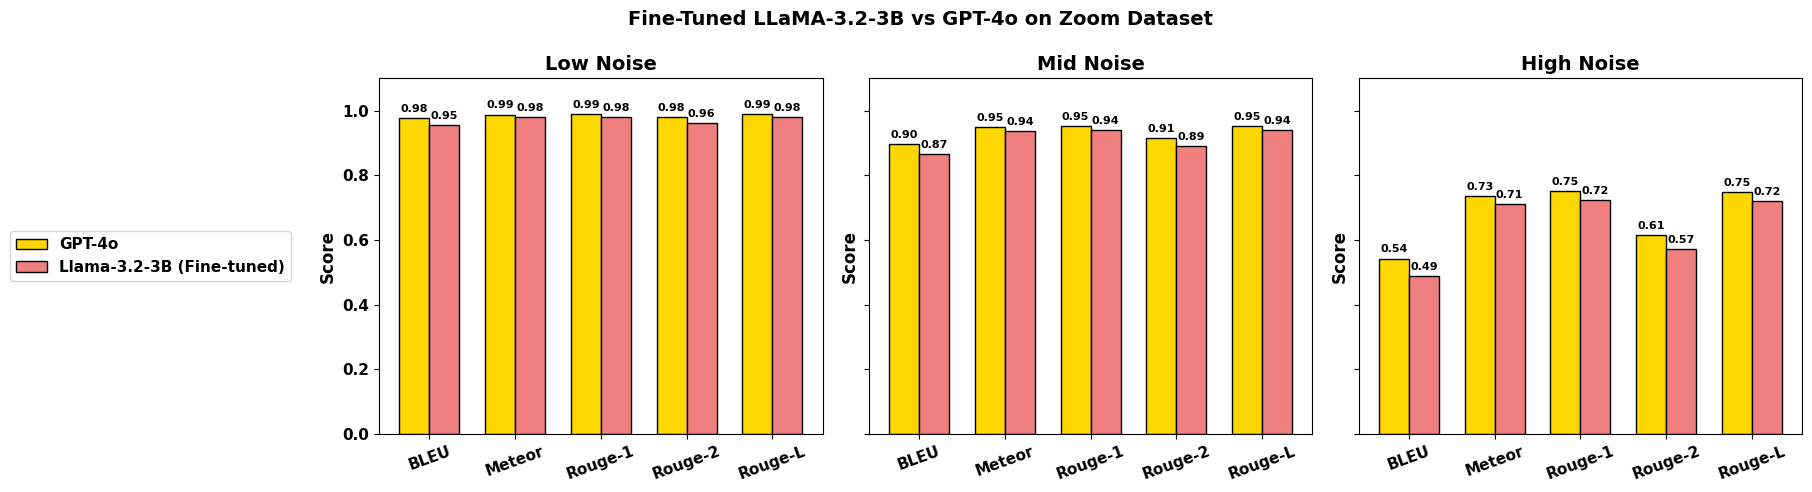

In [25]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({
    'font.size': 12,           # Increase base font size
    'font.weight': 'bold',     # Make all text bold
    'axes.labelweight': 'bold',
    'axes.titlesize': 14,      # Title font size
    'axes.titleweight': 'bold',
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11
})

# Models to compare
models = ["GPT-4o", "Llama-3.2-3B (Fine-tuned)"]

# Metrics and values for each noise level
metrics = ["BLEU", "Meteor", "Rouge-1", "Rouge-2", "Rouge-L"]
noise_levels = ["Low", "Mid", "High"]

# Values for each metric and noise level (index 4: GPT-4o, index 5: Fine-tuned 3B)
values = {
    "BLEU": [
        [0.976, 0.955],  # Low
        [0.896, 0.866],  # Mid
        [0.542, 0.489]   # High
    ],
    "Meteor": [
        [0.988, 0.979],
        [0.950, 0.938],
        [0.735, 0.710]
    ],
    "Rouge-1": [
        [0.989, 0.979],
        [0.952, 0.940],
        [0.750, 0.722]
    ],
    "Rouge-2": [
        [0.979, 0.962],
        [0.914, 0.891],
        [0.615, 0.572]
    ],
    "Rouge-L": [
        [0.989, 0.979],
        [0.952, 0.939],
        [0.749, 0.720]
    ]
}

# Plotting
fig, axs = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

colors = ['gold', 'lightcoral']
x = np.arange(len(metrics))
bar_width = 0.35

for i, level in enumerate(noise_levels):
    ax = axs[i]
    for j, model in enumerate(models):
        bar_values = [values[metric][i][j] for metric in metrics]
        bars = ax.bar(x + j * bar_width, bar_values, width=bar_width,
                      label=model if i == 0 else "", color=colors[j], edgecolor='black')
        
        # Annotate bars
        for bar in bars:
            height = bar.get_height()
            ax.annotate(f'{height:.2f}',
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 3),
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=8)

    ax.set_title(f"{level} Noise")
    ax.set_xticks(x + bar_width / 2)
    ax.set_xticklabels(metrics, rotation=20)
    ax.set_ylim(0, 1.1)
    ax.set_yticks(np.arange(0, 1.1, 0.2))
    ax.set_ylabel("Score")

# Move legend to the left outside the first plot
axs[0].legend(loc='center left', bbox_to_anchor=(-0.85, 0.5))
fig.suptitle("Fine-Tuned LLaMA-3.2-3B vs GPT-4o on Zoom Dataset", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('ft_zoom_performance.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.show()
